# 03 Optimisation Experiments

**Phase 4 of the project.** Every experiment changes one thing against the current best configuration, runs with 3 seeds, and is judged on the validation period (2026-06-17 to 2026-08-17) only. This notebook reproduces the key results from the saved runs in `runs/`; the full log with hypotheses and verdicts is `EXPERIMENTS.md`.

Each run was trained with `scripts/run_experiment.sh configs/<experiment>.json [seeds]`.

In [1]:
import sys
import json
from pathlib import Path
from itertools import combinations

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from rl_trading.data import load_raw_data, add_default_features
from rl_trading.train import prepare_splits
from rl_trading.envs import make_env, make_validation_envs
from rl_trading.agents import load_agent, EnsembleAgent
from rl_trading.evaluate import (summarize_experiment, plot_experiment_summary, diagnose_agent, validate)

RUNS, FIG_DIR = ROOT / "runs", ROOT / "figures"
BENCH = {"buy and hold": -0.0427, "always short": 0.0424}
pd.set_option("display.width", 180)

def run_config(exp_id):
    with open(RUNS / exp_id / "seed_0" / "config.json") as f:
        return json.load(f)

def val_returns(exp_id, seeds=(0, 1, 2)):
    _, per_seed = summarize_experiment(RUNS / exp_id, seeds=seeds)
    return per_seed[per_seed["env"] == "val"]["portfolio_return"].to_numpy()

## 1. All experiments at a glance

In [2]:
EXPERIMENTS = [
    ("baseline", "EXP-00 baseline", "TD3 DQN, TD3 hyperparameters", "reference"),
    ("exp01_normalize", "EXP-01", "z-score input normalisation", "rejected"),
    ("exp02_random_starts", "EXP-02", "random-start episodes of 720 steps", "inconclusive"),
    ("exp03_3years", "EXP-03", "3.2 years of training data", "inconclusive"),
    ("exp04_all_history", "EXP-04", "all history since 2017 (gap-free segments)", "inconclusive"),
    ("exp05_gamma09", "EXP-05", "γ 0.99 → 0.9", "kept"),
    ("exp06_gamma05", "EXP-06", "γ 0.99 → 0.5", "rejected"),
    ("exp07_double_dqn", "EXP-07", "Double DQN", "rejected"),
    ("exp08_normalize_3y", "EXP-08", "normalisation on 3 years", "rejected"),
    ("exp09_mr_features", "EXP-09", "mean-reversion features + normalisation", "rejected"),
    ("exp10_mr_all_history", "EXP-10", "EXP-09 on all history", "rejected"),
    ("exp11_mr_small_net", "EXP-11", "EXP-09 with hidden size 32", "rejected"),
    ("exp12_mr_turnover_penalty", "EXP-12", "EXP-09 + training turnover penalty", "rejected as single model"),
]
rows = []
for exp_id, name, change, verdict in EXPERIMENTS:
    v = val_returns(exp_id)
    rows.append({"experiment": name, "change": change, "val mean": f"{v.mean():+.2%}", "val std": f"{v.std(ddof=1):.2%}",
                 "seeds": " / ".join(f"{x:+.1%}" for x in v), "verdict": verdict})
pd.DataFrame(rows).set_index("experiment")

,change,val mean,val std,seeds,verdict
experiment,,,,,
EXP-00 baseline,"TD3 DQN, TD3 hyperparameters",-5.83%,4.33%,-9.9% / -1.3% / -6.3%,reference
EXP-01,z-score input normalisation,-23.58%,11.03%,-12.6% / -23.4% / -34.7%,rejected
EXP-02,random-start episodes of 720 steps,-3.71%,4.54%,-3.8% / +0.9% / -8.2%,inconclusive
EXP-03,3.2 years of training data,-7.64%,8.44%,-15.1% / -9.3% / +1.5%,inconclusive
EXP-04,all history since 2017 (gap-free segments),-9.15%,13.21%,-20.1% / -12.9% / +5.5%,inconclusive
EXP-05,γ 0.99 → 0.9,-3.97%,3.95%,-8.3% / -0.5% / -3.1%,kept
EXP-06,γ 0.99 → 0.5,-10.46%,7.14%,-16.6% / -12.1% / -2.6%,rejected
EXP-07,Double DQN,-6.25%,11.47%,-19.4% / -1.3% / +1.9%,rejected
EXP-08,normalisation on 3 years,-13.28%,9.11%,-21.8% / -14.4% / -3.7%,rejected


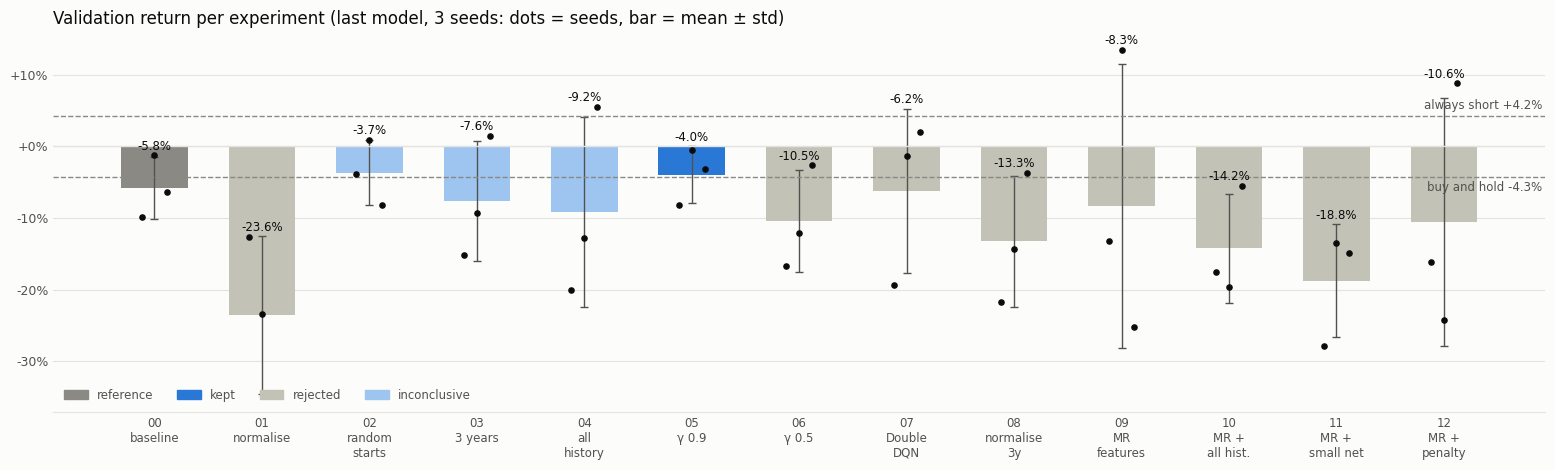

In [3]:
labels = ["00\nbaseline", "01\nnormalise", "02\nrandom\nstarts", "03\n3 years", "04\nall\nhistory", "05\nγ 0.9", "06\nγ 0.5",
          "07\nDouble\nDQN", "08\nnormalise\n3y", "09\nMR\nfeatures", "10\nMR +\nall hist.", "11\nMR +\nsmall net", "12\nMR +\npenalty"]
verdicts = ["reference", "rejected", "inconclusive", "inconclusive", "inconclusive", "kept", "rejected",
            "rejected", "rejected", "rejected", "rejected", "rejected", "rejected"]
fig = plot_experiment_summary([(e[0], l, v) for e, l, v in zip(EXPERIMENTS, labels, verdicts)], RUNS, benchmarks=BENCH,
                              title="Validation return per experiment (last model, 3 seeds: dots = seeds, bar = mean ± std)",
                              save_path=FIG_DIR / "phase4_experiment_summary.png")
plt.show()

Single networks are extremely noisy: the seed spread is often larger than the differences between experiments. That is why every conclusion below is also checked with diagnostics that measure the mechanism an experiment targets, not only its return.

## 2. Diagnostics: memorisation and overestimation

For each experiment and seed, one greedy episode on the training hours (the longest training frame) and one on validation:
- **corr train / corr val**: correlation between the position held and the next-hour market return. High in-sample and zero out-of-sample means memorisation.
- **overestimation**: mean predicted Q(s, a*) minus the discounted return realised afterwards (validation).

In [4]:
DIAG = ["baseline", "exp01_normalize", "exp03_3years", "exp04_all_history", "exp05_gamma09", "exp06_gamma05",
        "exp08_normalize_3y", "exp09_mr_features"]
diag_rows = []
for exp_id in DIAG:
    cfg = run_config(exp_id)
    splits, _ = prepare_splits(cfg)
    train_frame = max(splits.get("dev_train_segments", [splits["dev_train"]]), key=len)
    envs = {"train": make_env(train_frame, positions=cfg["positions"]), "val": make_env(splits["val"], positions=cfg["positions"])}
    for seed in (0, 1, 2):
        d = diagnose_agent(load_agent(RUNS / exp_id / f"seed_{seed}" / "last.pt"), envs, gamma=cfg["agent_params"]["gamma"])
        diag_rows.append({"experiment": exp_id, "training hours": len(train_frame), "gamma": cfg["agent_params"]["gamma"],
                          "corr train": d.loc["train", "corr_pos_next_1h"], "corr val": d.loc["val", "corr_pos_next_1h"],
                          "overestimation": d.loc["val", "overestimation"], "trades val": d.loc["val", "changes"]})
diag = pd.DataFrame(diag_rows).groupby("experiment", sort=False).mean()
diag.round(4)

Downloaded data: 9,672 candles, 2025-08-10 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 7,296 candles, 2025-08-17 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
Downloaded data: 9,672 candles, 2025-08-10 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 7,296 candles, 2025-08-17 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candl

,training hours,gamma,corr train,corr val,overestimation,trades val
experiment,,,,,,
baseline,7296.0,0.99,0.0503,0.0023,0.0427,201.3333
exp01_normalize,7296.0,0.99,0.2908,-0.0132,0.2555,987.3333
exp03_3years,28152.0,0.99,0.0152,-0.0177,0.0352,107.6667
exp04_all_history,28163.0,0.99,0.0099,-0.0077,0.0419,907.6667
exp05_gamma09,28152.0,0.90,0.0097,0.0137,0.0030,82.6667
exp06_gamma05,28152.0,0.50,0.0141,-0.0214,0.0007,452.6667
exp08_normalize_3y,28152.0,0.90,0.1483,-0.0139,0.0117,493.0000
exp09_mr_features,28152.0,0.90,0.2307,0.0083,0.0168,926.3333


- **Memorisation falls with more data**: corr train 0.050 (1 year) → 0.015 (3 years) → 0.010 (all history), while corr val stays around zero. More data removes memorisation, but the agent then falls back to a near-constant bet.
- **Normalised inputs bring memorisation back** (EXP-01, EXP-08, EXP-09: corr train 0.15 to 0.29) together with hundreds of trades: the network can now resolve states and uses that to fit noise.
- **γ controls overestimation**: 0.035 at γ = 0.99, 0.003 at γ = 0.9, 0.0007 at γ = 0.5. The max bias of Q-learning is amplified by about 1 / (1 - γ); γ = 0.5 is too short-sighted to pay back fees (more trades).

## 3. Is there any signal? (feature analysis)

Rank correlation of causal candidate features with the next-hour return on the 3-year dev-train and on validation. Noise level (2 standard errors): about ±0.012 on dev-train, ±0.052 on validation. The targets are used only for this analysis, never as features.

In [5]:
raw = load_raw_data(ROOT / "data", train_start=pd.Timestamp("2023-04-01", tz="UTC"))
df = add_default_features(raw)
log_close = np.log(df["close"])
step = log_close.diff()
cand = pd.DataFrame(index=df.index)
for k in ["feature_close", "feature_high", "feature_low", "feature_volume"]:
    cand[k.replace("feature_", "default_")] = df[k]
for h in [4, 24, 72, 168]:
    cand[f"ret_{h}h"] = log_close.diff(h)
for h in [24, 168]:
    cand[f"vol_{h}h"] = step.rolling(h).std()
for h in [24, 168]:
    cand[f"dist_sma_{h}h"] = df["close"] / df["close"].rolling(h).mean() - 1
gain, loss = step.clip(lower=0).rolling(14).mean(), (-step.clip(upper=0)).rolling(14).mean()
cand["rsi_14h"] = gain / (gain + loss)
log_volume = np.log(df["volume"])
cand["volume_z_168h"] = (log_volume - log_volume.rolling(168).mean()) / log_volume.rolling(168).std()
cand["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
next_hour = step.shift(-1)   # analysis target only

corr = {}
for name, (a, b) in {"dev-train (3y)": ("2023-04-01", "2026-06-17"), "validation": ("2026-06-17", "2026-08-17")}.items():
    m = (df.index >= pd.Timestamp(a, tz="UTC")) & (df.index < pd.Timestamp(b, tz="UTC"))
    corr[name] = cand[m].rank().corrwith(next_hour[m].rank())
pd.DataFrame(corr).round(3)

Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours


,dev-train (3y),validation
default_close,-0.062,-0.031
default_high,0.064,0.031
default_low,0.047,0.023
default_volume,0.008,0.002
ret_4h,-0.051,-0.060
ret_24h,-0.041,-0.037
ret_72h,-0.015,-0.058
ret_168h,-0.006,-0.023
vol_24h,0.015,0.023
vol_168h,0.012,0.001


Short-term **mean reversion** is small but consistent: the last-hour return, the 4-hour return, the distance to the 24-hour average and the RSI all correlate negatively with the next hour on both periods. Volume, volatility and time of day carry no information. A correlation of about 0.05 is worth roughly 0.02% per hour, about the size of a position change's fee. These signals form the mean-reversion feature set of EXP-09 to EXP-12.

## 4. Ensembles: averaging the Q-values of several networks

Single networks with normalised mean-reversion features memorise different noise per seed, so each one is a high-variance estimator. Averaging their Q-values (`EnsembleAgent`) reduces this variance. The networks disagree least about the flat position (no market exposure) and most about the exposed positions, so averaging shrinks the exposed actions towards a common mean that lies just below flat: the ensemble is flat unless the networks agree on an edge (measured in notebook 04).

Related methods: Averaged-DQN (Anschel, Baram and Shimkin, ICML 2017) averages the previous Q estimates of one network to reduce target variance; Bootstrapped DQN (Osband, Blundell, Pritzel and Van Roy, NeurIPS 2016) trains several Q heads for exploration and can vote across them when acting. Here, independently trained networks are averaged only when acting.

**EXP-13 (pre-registered):** fresh seeds 3 to 5; criterion: the ensemble beats the mean single seed and trades less in at least 2 of 3 configurations.

In [6]:
def ensemble_vs_single(exp_id, seeds):
    cfg = run_config(exp_id)
    splits, _ = prepare_splits(cfg)
    envs = make_validation_envs(splits["val"], positions=cfg["positions"])
    _, per_seed = summarize_experiment(RUNS / exp_id, seeds=seeds)
    single = per_seed[per_seed["env"] == "val"]
    summary, _ = validate(EnsembleAgent([load_agent(RUNS / exp_id / f"seed_{s}" / "last.pt") for s in seeds]), envs, num_episodes=10)
    return {"config": exp_id, "seeds": f"{seeds[0]} to {seeds[-1]}",
            "single mean": single["portfolio_return"].mean(), "single trades": single["n_changes"].mean(),
            "ensemble": summary.loc["val", "portfolio_return"], "ensemble trades": summary.loc["val", "n_changes"],
            "ensemble val_w1": summary.loc["val_w1", "portfolio_return"], "ensemble val_w2": summary.loc["val_w2", "portfolio_return"]}

exp13 = pd.DataFrame([ensemble_vs_single(e, (3, 4, 5)) for e in ["exp05_gamma09", "exp09_mr_features", "exp12_mr_turnover_penalty"]])
exp13.round(4)

Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 c

,config,seeds,single mean,single trades,ensemble,ensemble trades,ensemble val_w1,ensemble val_w2
0,exp05_gamma09,3 to 5,-0.0140,117.5667,0.2765,238.9,0.2507,0.0151
1,exp09_mr_features,3 to 5,-0.0957,880.2667,-0.0151,721.9,0.0212,-0.0380
2,exp12_mr_turnover_penalty,3 to 5,-0.1388,752.7000,-0.0321,601.9,-0.0274,-0.0118


The ensemble beats the mean single seed in all three configurations and trades less in two: **criterion met, ensemble kept.** (The EXP-05 ensemble value is a lucky draw: its averaged Q-values are practically tied, see `EXPERIMENTS.md`.)

**EXP-14 (pre-registered):** 6-network ensembles on fresh seeds 6 to 11; criteria: (1) above the mean single seed and buy and hold, (2) positive and above always short.

In [7]:
exp14 = pd.DataFrame([ensemble_vs_single(e, tuple(range(6, 12))) for e in ["exp12_mr_turnover_penalty", "exp09_mr_features"]])
exp14["criterion 1"] = (exp14["ensemble"] > exp14["single mean"]) & (exp14["ensemble"] > BENCH["buy and hold"])
exp14["criterion 2"] = (exp14["ensemble"] > 0) & (exp14["ensemble"] > BENCH["always short"])
exp14.round(4)

Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours


,config,seeds,single mean,single trades,ensemble,ensemble trades,ensemble val_w1,ensemble val_w2,criterion 1,criterion 2
0,exp12_mr_turnover_penalty,6 to 11,-0.1798,731.1333,-0.0281,288.1,-0.0057,-0.0256,True,False
1,exp09_mr_features,6 to 11,-0.0370,881.8833,-0.0217,413.9,-0.0012,-0.0209,True,False


Criterion 1 met, criterion 2 not met: 6 networks rescue the configurations (single seeds -18% and -4% become about -3% and -2%) but are not yet positive.

### Validation return vs ensemble size

For each ensemble size k, 20 random subsets of seeds 0 to 11 (k = 12: the full set), validation with 3 episodes each (exploratory).

In [8]:
rng = np.random.default_rng(0)
size_curve = {}
for exp_id in ["exp09_mr_features", "exp12_mr_turnover_penalty"]:
    cfg = run_config(exp_id)
    splits, _ = prepare_splits(cfg)
    val_env = {"val": make_validation_envs(splits["val"], positions=cfg["positions"])["val"]}
    agents = [load_agent(RUNS / exp_id / f"seed_{s}" / "last.pt") for s in range(12)]
    for k in [1, 2, 3, 4, 6, 8, 12]:
        subsets = [tuple(range(12))] if k == 12 else [tuple(sorted(rng.choice(12, k, replace=False))) for _ in range(20)]
        values, trades = [], []
        for subset in subsets:
            agent = agents[subset[0]] if k == 1 else EnsembleAgent([agents[s] for s in subset])
            summary, _ = validate(agent, val_env, num_episodes=3)
            values.append(summary.loc["val", "portfolio_return"])
            trades.append(summary.loc["val", "n_changes"])
        size_curve[(exp_id, k)] = (np.array(values), np.array(trades))

pd.DataFrame([{"config": e, "k": k, "median": v.mean() if k == 12 else np.median(v), "p10": np.percentile(v, 10),
               "p90": np.percentile(v, 90), "median trades": np.median(t)} for (e, k), (v, t) in size_curve.items()]).round(4)

Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
Downloaded data: 30,528 candles, 2023-03-25 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 28,152 candles, 2023-04-01 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours


,config,k,median,p10,p90,median trades
0,exp09_mr_features,1,-0.1315,-0.2522,0.2351,880.0000
1,exp09_mr_features,2,-0.1314,-0.2301,0.0340,752.5000
2,exp09_mr_features,3,-0.0526,-0.1568,0.0944,662.3333
3,exp09_mr_features,4,-0.0207,-0.1447,0.0899,490.5000
4,exp09_mr_features,6,-0.0160,-0.0606,0.0678,413.5000
5,exp09_mr_features,8,0.0167,-0.0224,0.0556,306.0000
6,exp09_mr_features,12,0.0499,0.0499,0.0499,205.0000
7,exp12_mr_turnover_penalty,1,-0.1581,-0.2421,0.0877,779.0000
8,exp12_mr_turnover_penalty,2,-0.0845,-0.1401,-0.0122,633.6667
9,exp12_mr_turnover_penalty,3,-0.0239,-0.0894,0.0911,536.3333


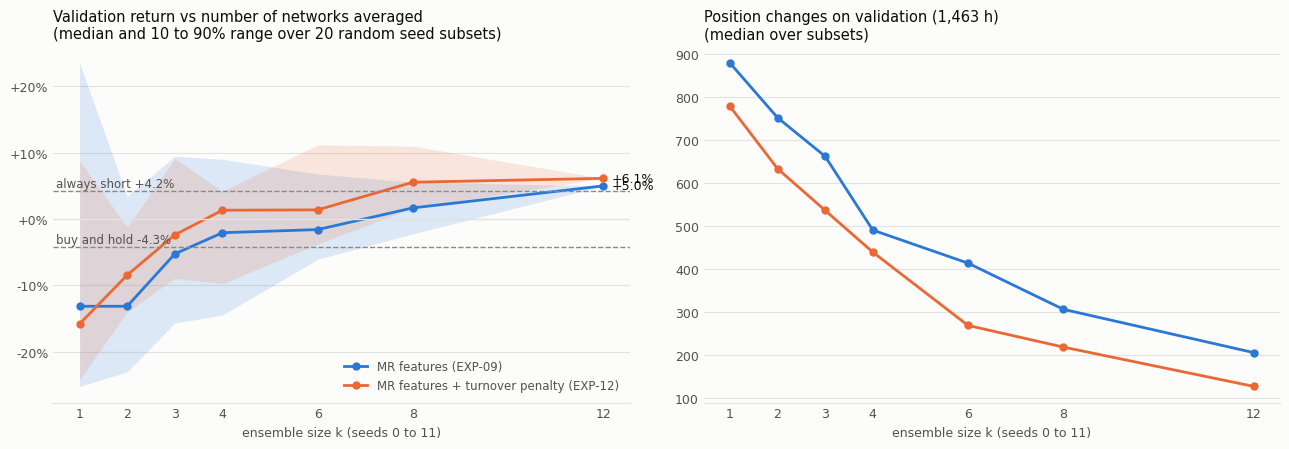

In [9]:
SURF, INK, INK2, GRID, NEUTRAL = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#8a8984"
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), facecolor=SURF)
for ax in axes:
    ax.set_facecolor(SURF)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=9, length=0)
ks = [1, 2, 3, 4, 6, 8, 12]
for (exp_id, label), color in zip([("exp09_mr_features", "MR features (EXP-09)"),
                                   ("exp12_mr_turnover_penalty", "MR features + turnover penalty (EXP-12)")], ["#2a78d6", "#eb6834"]):
    med = [np.median(size_curve[(exp_id, k)][0]) for k in ks]
    lo = [np.percentile(size_curve[(exp_id, k)][0], 10) for k in ks]
    hi = [np.percentile(size_curve[(exp_id, k)][0], 90) for k in ks]
    axes[0].fill_between(ks, lo, hi, color=color, alpha=0.15, lw=0)
    axes[0].plot(ks, med, "-o", color=color, lw=2, ms=5, label=label)
    axes[0].annotate(f"{med[-1]:+.1%}", (ks[-1], med[-1]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=INK)
    axes[1].plot(ks, [np.median(size_curve[(exp_id, k)][1]) for k in ks], "-o", color=color, lw=2, ms=5, label=label)
for value, label in [(BENCH["always short"], "always short +4.2%"), (BENCH["buy and hold"], "buy and hold -4.3%")]:
    axes[0].axhline(value, color=NEUTRAL, ls="--", lw=1)
    axes[0].annotate(label, (0.0, value), xycoords=("axes fraction", "data"), xytext=(2, 3), textcoords="offset points", fontsize=8.5, color=INK2)
axes[0].axhline(0, color=GRID, lw=1)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.0%}"))
axes[0].set_title("Validation return vs number of networks averaged\n(median and 10 to 90% range over 20 random seed subsets)", loc="left", color=INK, fontsize=10.5)
axes[1].set_title("Position changes on validation (1,463 h)\n(median over subsets)", loc="left", color=INK, fontsize=10.5)
for ax in axes:
    ax.set_xticks(ks)
    ax.set_xlabel("ensemble size k (seeds 0 to 11)", color=INK2, fontsize=9)
axes[0].legend(frameon=False, fontsize=8.5, labelcolor=INK2, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "phase4_ensemble_size.png", dpi=150, facecolor=SURF)
plt.show()

The median validation return rises and the spread shrinks with every additional network, while trading falls by a factor of 4 to 6. This is variance reduction: each network is a high-variance estimator, and averaging keeps the shared signal. With 12 networks both configurations are positive and above always short on validation. EXP-12 is ahead at every size from 3 networks on and trades less.

## 5. Final choice

- **Configuration:** EXP-12 (γ 0.9, 3 years, random-start episodes, mean-reversion features with normalisation, training-only turnover penalty).
- **Ensemble:** 20 networks, seeds 0 to 19, composition fixed before seeds 12 to 19 were trained.
- **Deviation stated openly:** the EXP-14 rule favoured EXP-09 on one 6-network comparison inside the noise; the ensemble size analysis favours EXP-12 at every size. The choice is not driven by the eval month (the ensemble is mostly flat, not long).

The frozen model, its validation result and the one evaluation on the eval month are in notebook 04.